
# Preprocessing Clifford gates

In this example, we implement the Deutsch-Jozsa algorithm which determines whether
a function is *balanced* or *constant*.
Since this algorithm is written only with Clifford gates, we can expect the preprocessing of Clifford gates
would significantly improve the MBQC pattern simulation.

This notebook is an adaptation of the one found [here](https://graphix.readthedocs.io/en/latest/gallery/deutsch_jozsa.html).

In [ ]:
from __future__ import annotations
import numpy as np
from graphix import Circuit
from graphix.command import CommandKind

Now we implement the algorithm as a general function that works for any number of input qubits `n`.
The total number of qubits is `n + 1` (n input qubits + 1 ancilla).

The `oracle_type` parameter selects the oracle:
- `'balanced'`: flips the ancilla for exactly half the inputs (using CNOT from a subset of input qubits)
- `'constant_0'`: always returns 0 (identity — does nothing)
- `'constant_1'`: always returns 1 (flips the ancilla for all inputs)

You can also pass a custom list of `marked_qubits` to define which input qubits participate in the balanced oracle.

In [8]:
def deutsch_jozsa_circuit(n, oracle_type='balanced', marked_qubits=None):
    """
    Build a Deutsch-Jozsa circuit for n input qubits.

    Parameters
    ----------
    n : int
        Number of input qubits (total qubits = n + 1 including ancilla).
    oracle_type : str
        'balanced'   - oracle flips ancilla for half the inputs.
        'constant_0' - oracle does nothing (f(x) = 0 for all x).
        'constant_1' - oracle flips ancilla unconditionally (f(x) = 1 for all x).
    marked_qubits : list[int] or None
        For 'balanced' oracle: which input qubits (0..n-1) are used in CNOTs.
        If None, defaults to all input qubits (a valid balanced function).

    Returns
    -------
    circuit : graphix.Circuit
    """
    total_qubits = n + 1
    ancilla = n  # last qubit is the ancilla

    circuit = Circuit(total_qubits)

    # --- Initialization ---
    # Apply H to all input qubits
    for i in range(n):
        circuit.h(i)

    # Prepare ancilla in |-> state
    circuit.x(ancilla)
    circuit.h(ancilla)

    # --- Oracle ---
    if oracle_type == 'balanced':
        if marked_qubits is None:
            marked_qubits = list(range(n))  # all input qubits
        for q in marked_qubits:
            circuit.cnot(q, ancilla)

    elif oracle_type == 'constant_0':
        pass  # f(x) = 0: do nothing

    elif oracle_type == 'constant_1':
        circuit.x(ancilla)  # f(x) = 1: flip ancilla unconditionally

    else:
        raise ValueError(f"Unknown oracle_type '{oracle_type}'. Use 'balanced', 'constant_0', or 'constant_1'.")

    # --- Final Hadamards on input qubits ---
    for i in range(n):
        circuit.h(i)

    return circuit

Choose the number of input qubits and the oracle type, then transpile into an MBQC measurement pattern.

Deutsch-Jozsa with 10 input qubits, oracle = 'balanced'
Full resource graph (before preprocessing):
  Nodes: 54, Edges: 53
  Is connected: True
N(11) E(0,11) M(0) X(11,{0}) N(12) E(1,12) M(1) X(12,{1}) N(13) E(2,13) M(2) X(13,{2}) N(14) E(3,14)...(178 more commands)
Flow detected in the graph.


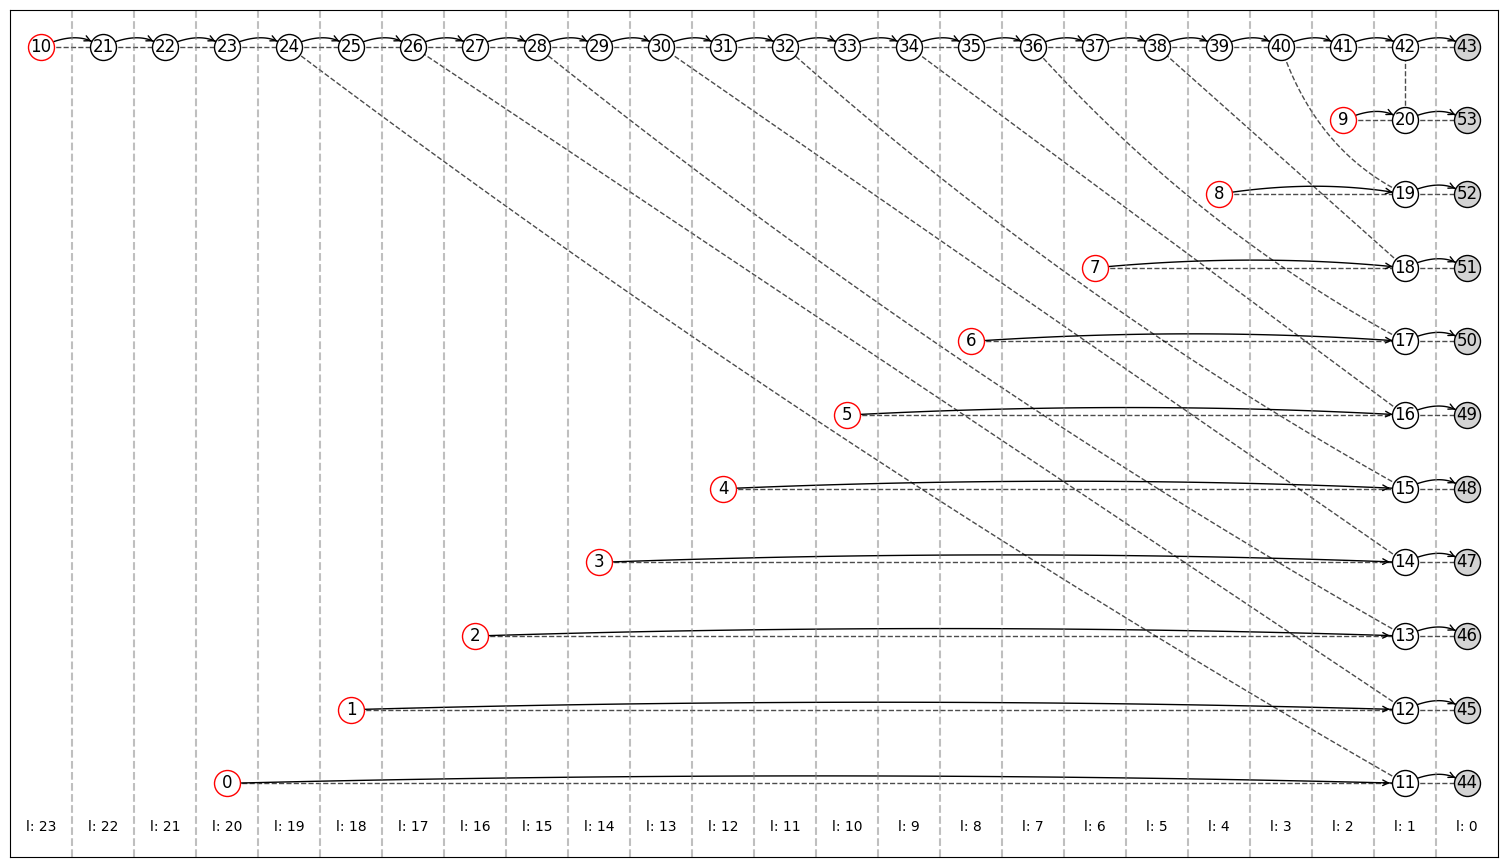

In [108]:
import networkx as nx
import matplotlib.pyplot as plt

def pattern_to_networkx(pattern):
    """
    Extract the resource graph state from a Graphix pattern as a NetworkX graph.
    """
    nodes, edges = pattern.get_graph()
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    return G

# --- Configuration ---
n_input_qubits = 10         # change this to any number of input qubits
oracle = 'balanced'          # 'balanced', 'constant_0', or 'constant_1'
marked = None                # e.g. [0, 2] for a custom balanced oracle, or None for default

circuit = deutsch_jozsa_circuit(n_input_qubits, oracle_type=oracle, marked_qubits=marked)

pattern = circuit.transpile().pattern

# Extract the graph IMMEDIATELY after transpilation (before ANY preprocessing)
G_full = pattern_to_networkx(pattern)

print(f"Deutsch-Jozsa with {n_input_qubits} input qubits, oracle = '{oracle}'")
print(f"Full resource graph (before preprocessing):")
print(f"  Nodes: {G_full.number_of_nodes()}, Edges: {G_full.number_of_edges()}")
print(f"  Is connected: {nx.is_connected(G_full)}")

print(pattern.to_ascii(left_to_right=True, limit=15))
pattern.draw_graph(flow_from_pattern=False)

This seems to require quite a large graph state.
However, we know that Pauli measurements can be preprocessed with the graph state simulator.
To do so, let us first standardize and shift signals, so that measurements are less interdependent.

In [109]:
pattern.standardize()
pattern.shift_signals()
print(pattern.to_ascii(left_to_right=True, limit=15))

N(11) N(12) N(13) N(14) N(15) N(16) N(17) N(18) N(19) N(20) N(21) N(22) N(23) N(24)...(147 more commands)


Now we preprocess all Pauli measurements



N(43) N(44) N(45) N(46) N(47) N(48) N(49) N(50) N(51) N(52) N(53) C(43,H)
The pattern is not consistent with flow or gflow structure.


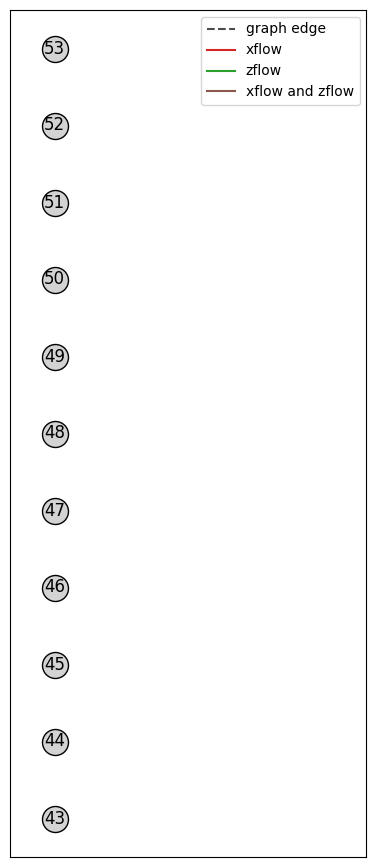

In [110]:
pattern.perform_pauli_measurements()
print(
    pattern.to_ascii(
        left_to_right=True,
        limit=16,
        target=[CommandKind.N, CommandKind.M, CommandKind.C],
    )
)
pattern.standardize()
pattern.draw_graph(flow_from_pattern=True)

Since all operations of the original circuit are Clifford, all measurements in the measurement pattern are Pauli measurements:
So the preprocessing has done all the necessary computations, and all nodes are isolated with no further measurements required.
Let us make sure the result is correct:



In [111]:
# out_state = pattern.simulate_pattern()
# state = circuit.simulate_statevector().statevec
# overlap = np.abs(np.dot(state.psi.flatten().conjugate(), out_state.psi.flatten()))
# print(f"Overlap of states: {overlap:.10f}")

Resource graph state for Deutsch-Jozsa (10 input qubits):
  Number of nodes (qubits): 54
  Number of edges (CZ gates): 53
  Is connected: True


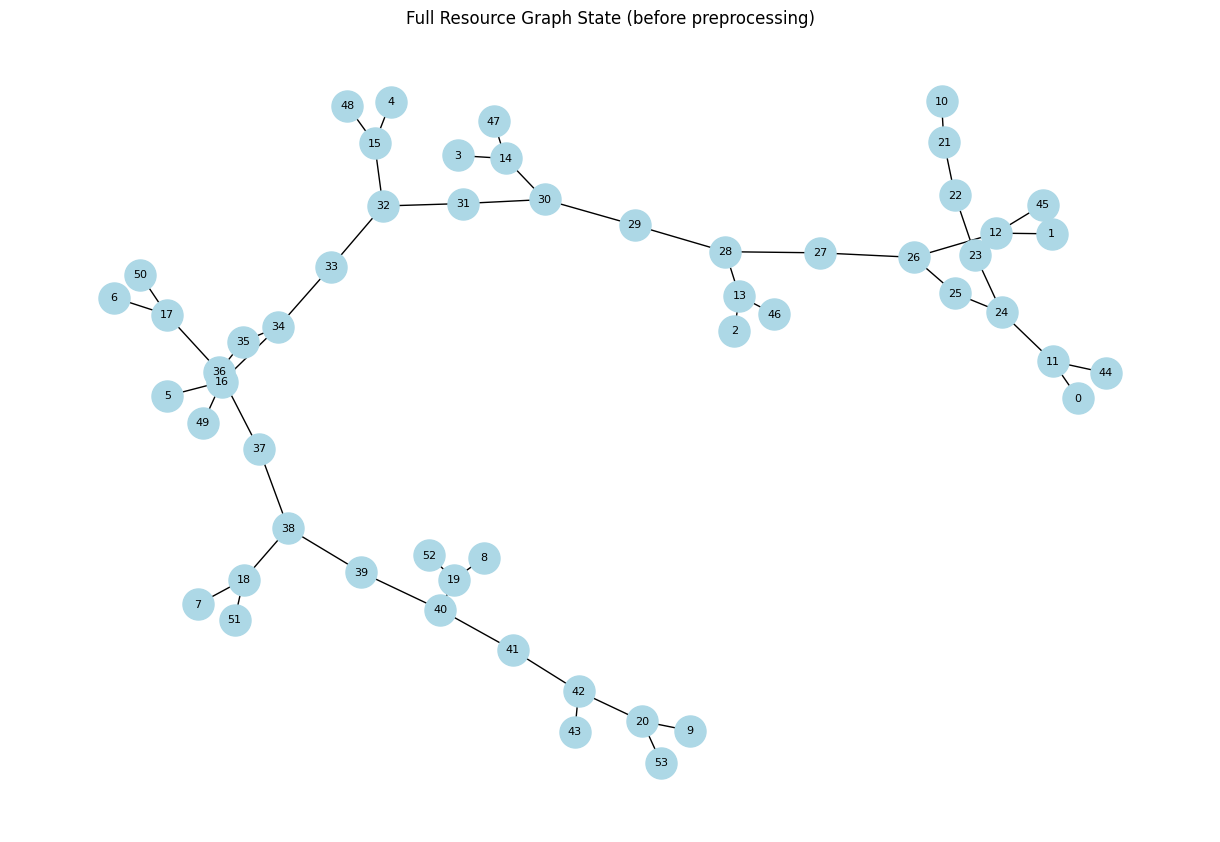

In [112]:
import matplotlib.pyplot as plt

# G_full was extracted in cell 6 BEFORE preprocessing
# Here we just visualize it

print(f"Resource graph state for Deutsch-Jozsa ({n_input_qubits} input qubits):")
print(f"  Number of nodes (qubits): {G_full.number_of_nodes()}")
print(f"  Number of edges (CZ gates): {G_full.number_of_edges()}")
print(f"  Is connected: {nx.is_connected(G_full)}")

# Visualize the full (connected) graph
plt.figure(figsize=(12, 8))
nx.draw(G_full, with_labels=True, node_color='lightblue', node_size=500, font_size=8)
plt.title("Full Resource Graph State (before preprocessing)")
plt.show()